In [ ]:
import pandas as pd
import numpy as np

# Load the loan prediction dataset
df = pd.read_csv('/loan_approval_dataset.csv')

# Print basic shape and columns information
print("Dataset Rows and Columns:", df.shape)
print("\nList of Dataset Columns:", df.columns.tolist())
print("\nCheck for Missing Values:\n", df.isnull().sum())


Dataset Rows and Columns: (4269, 13)

List of Dataset Columns: ['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

Check for Missing Values:
 loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Clean blank spaces from column names
df.columns = df.columns.str.strip()

# Fill empty numerical cells with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill empty text cells with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")

# Remove exact duplicates
df = df.drop_duplicates()

# Encode text categories to numeric labels
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str).str.strip())

# Normalize continuous income and loan figures
scaler = StandardScaler()
if 'income_annum' in df.columns:
    df[['income_annum', 'loan_amount']] = scaler.fit_transform(df[['income_annum', 'loan_amount']])

print("Data cleaning and preprocessing successfully completed!")


Data cleaning and preprocessing successfully completed!


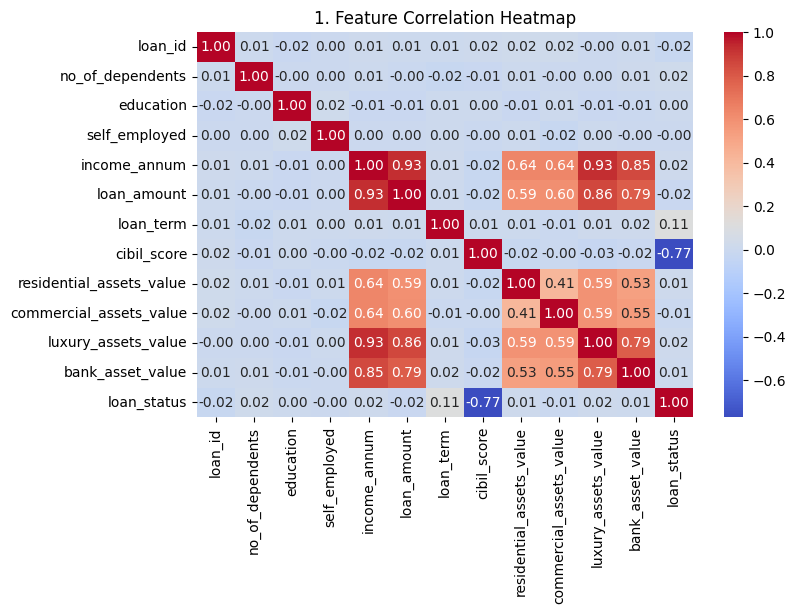

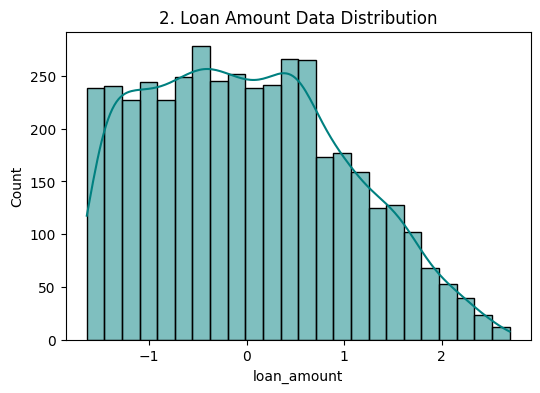

/tmp/ipykernel_1609/2136079876.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


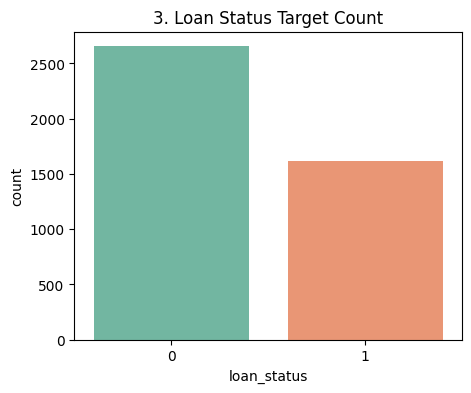

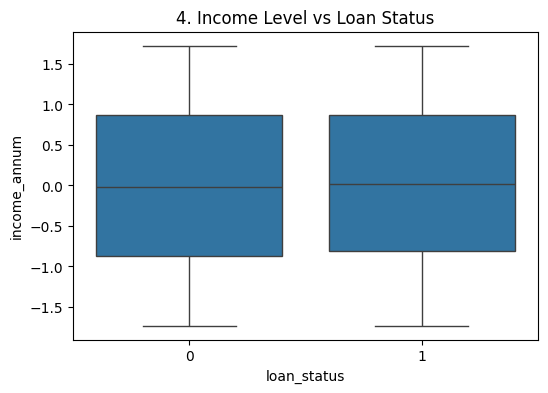

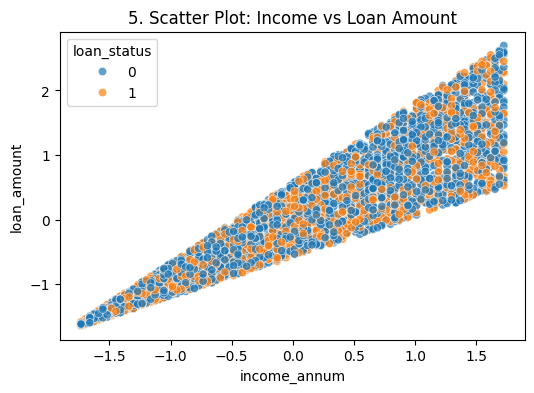

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Complete Correlation Heatmap matrix
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('1. Feature Correlation Heatmap')
plt.show()

# Plot 2: Numerical Loan Amount Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['loan_amount'], kde=True, color='teal')
plt.title('2. Loan Amount Data Distribution')
plt.show()

# Plot 3: Target Loan Status Balances
plt.figure(figsize=(5, 4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('3. Loan Status Target Count')
plt.show()

# Plot 4: Annual Income Grouped by Status
plt.figure(figsize=(6, 4))
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title('4. Income Level vs Loan Status')
plt.show()

# Plot 5: Scatter Relationship (Income vs Loan Amount)
plt.figure(figsize=(6, 4))
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df, alpha=0.7)
plt.title('5. Scatter Plot: Income vs Loan Amount')
plt.show()


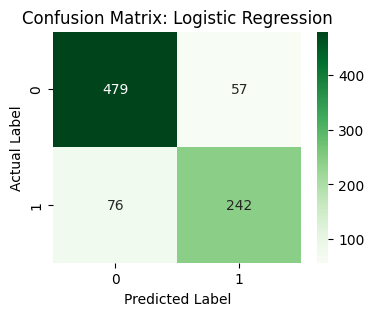

Logistic Regression Evaluation Done.
----------------------------------------


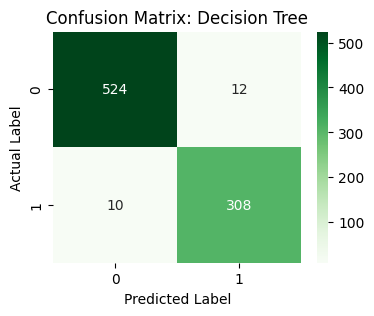

Decision Tree Evaluation Done.
----------------------------------------


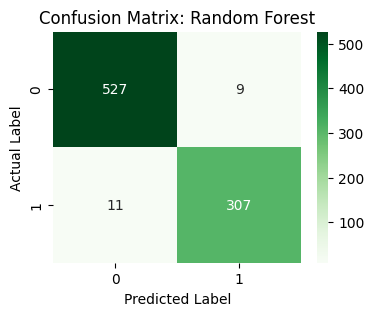

Random Forest Evaluation Done.
----------------------------------------


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Separate input features (X) from the Kaggle target outcome label (y)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Split data into Train (80%) and Test (20%) partitions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the 3 required classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Loop to fit each machine learning model and print metrics
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate operational scores
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Save statistics for step 6 comparison table
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

    # Render Step 5 Confusion Matrices plots
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print(f"{name} Evaluation Done.\n" + "-"*40)


In [ ]:
# Convert tracking variables into a structured comparison table
df_results = pd.DataFrame(results).T

print("--- Final Model Metrics Comparison Table ---")
print(df_results)

# Find and suggest the best model mathematically
best_model_name = df_results['Accuracy'].idxmax()
best_model_score = df_results.loc[best_model_name, 'Accuracy']

print("\n================ FINAL CONCLUSION ================")
print(f"The best performing model on Kaggle data is: {best_model_name}")
print(f"Achieved maximum validation accuracy of: {best_model_score:.4f}")


--- Final Model Metrics Comparison Table ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.844262   0.836214  0.827332  0.831267
Decision Tree        0.974239   0.971887  0.973083  0.972478
Random Forest        0.976581   0.975536  0.974309  0.974916

================ FINAL CONCLUSION ================
The best performing model on Kaggle data is: Random Forest
Achieved maximum validation accuracy of: 0.9766
